In [7]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [8]:
# ── 通道定義 & 五腦區分組 ──
CH_NAMES = [
    'Fp1','Fz','F3','F7','FT9','FC5','FC1',
    'C3','T7','TP9','CP5','CP1','Pz','P3','P7',
    'O1','Oz','O2',
    'P4','P8','TP10','CP6','CP2','Cz','C4','T8',
    'FT10','FC6','FC2','F4','F8','Fp2'
]

REGIONS = {
    'Frontal':   [0, 31, 2, 29, 3, 30, 1],
    'Central':   [7, 24, 23, 6, 28, 5, 27],
    'Parietal':  [13, 18, 14, 19, 12, 11, 22, 10, 21],
    'Temporal':  [8, 25, 4, 26, 9, 20],
    'Occipital': [15, 17, 16],
}

BAND_NAMES  = ['delta', 'theta', 'alpha', 'beta', 'gamma']
CLASS_NAMES = ['amateur', 'master', 'prof']

In [9]:
# ── 資料載入 ──

def get_subject_id(filename):
    return filename.split('_ses-')[0]

def scan_folder(folder_path):
    result = {}
    for fname in sorted(os.listdir(folder_path)):
        if fname.endswith('.mat'):
            result[get_subject_id(fname)] = os.path.join(folder_path, fname)
    return result

def load_plv(filepath):
    with h5py.File(filepath, 'r') as f:
        rm = f['result_mats']
        bands_data = [np.array(rm[band]) for band in BAND_NAMES]
    return np.array(bands_data)  # (5, 200, 32, 32)

def load_plv_group(ss01_map, ss02_map, ss03_map, complete_subs):
    X1, X2, X3 = [], [], []
    for sub_id in complete_subs:
        X1.append(load_plv(ss01_map[sub_id]))
        X2.append(load_plv(ss02_map[sub_id]))
        X3.append(load_plv(ss03_map[sub_id]))
    return np.array(X1), np.array(X2), np.array(X3)

def load_band_energy(filepath):
    with h5py.File(filepath, 'r') as f:
        data = np.array(f['band_energy']).T
    return data  # (32ch, 39time, 5bands)

def load_be_group(ss01_map, ss02_map, ss03_map, complete_subs):
    X1, X2, X3 = [], [], []
    for sub_id in complete_subs:
        X1.append(load_band_energy(ss01_map[sub_id]))
        X2.append(load_band_energy(ss02_map[sub_id]))
        X3.append(load_band_energy(ss03_map[sub_id]))
    return np.array(X1), np.array(X2), np.array(X3)

BASE_PLV = {
    'amateur': r'D:\Tseng\圍棋\amateur\PLV_Results_2026',
    'master':  r'D:\Tseng\圍棋\master\PLV_Results_2026',
    'prof':    r'D:\Tseng\圍棋\prof\PLV_Results_2026',
}
BASE_BE = {
    'amateur': r'D:\Tseng\圍棋\amateur\band_energy_batch_outputs_2026',
    'master':  r'D:\Tseng\圍棋\master\band_energy_batch_outputs_2026',
    'prof':    r'D:\Tseng\圍棋\prof\band_energy_batch_outputs_2026',
}

# 載入 PLV
plv_maps, complete = {}, {}
for group in CLASS_NAMES:
    paths = {s: os.path.join(BASE_PLV[group], s) for s in ['ss01','ss02','ss03']}
    m1, m2, m3 = scan_folder(paths['ss01']), scan_folder(paths['ss02']), scan_folder(paths['ss03'])
    plv_maps[group] = (m1, m2, m3)
    complete[group] = sorted(set(m1) & set(m2) & set(m3))
    print(f'[{group}] 完整 subject：{len(complete[group])} 人')

print('\n載入 PLV 資料...')
X_a1, X_a2, X_a3 = load_plv_group(*plv_maps['amateur'], complete['amateur'])
X_m1, X_m2, X_m3 = load_plv_group(*plv_maps['master'],  complete['master'])
X_p1, X_p2, X_p3 = load_plv_group(*plv_maps['prof'],    complete['prof'])
print(f'PLV shape: {X_a1.shape}, {X_m1.shape}, {X_p1.shape}')

print('\n載入 Band Energy 資料...')
be_maps = {}
for group in CLASS_NAMES:
    paths = {s: os.path.join(BASE_BE[group], s) for s in ['ss01','ss02','ss03']}
    be_maps[group] = (scan_folder(paths['ss01']), scan_folder(paths['ss02']), scan_folder(paths['ss03']))

BE_a1, BE_a2, BE_a3 = load_be_group(*be_maps['amateur'], complete['amateur'])
BE_m1, BE_m2, BE_m3 = load_be_group(*be_maps['master'],  complete['master'])
BE_p1, BE_p2, BE_p3 = load_be_group(*be_maps['prof'],    complete['prof'])
print(f'BE shape: {BE_a1.shape}')

[amateur] 完整 subject：28 人
[master] 完整 subject：20 人
[prof] 完整 subject：8 人

載入 PLV 資料...
PLV shape: (28, 5, 200, 32, 32), (20, 5, 200, 32, 32), (8, 5, 200, 32, 32)

載入 Band Energy 資料...
BE shape: (28, 32, 39, 5)


In [10]:
# ── 特徵提取 & 標籤準備 ──

triu_idx = np.triu_indices(32, k=1)

def extract_plv_features(X, ch_idx=None):
    X_mean = X.mean(axis=2)
    if ch_idx is not None:
        n_ch = len(ch_idx)
        tri = np.triu_indices(n_ch, k=1)
        ix = np.ix_(ch_idx, ch_idx)
        feats = [X_mean[:, b][np.ix_(np.arange(len(X_mean)), ch_idx, ch_idx)][:, tri[0], tri[1]]
                 for b in range(5)]
    else:
        tri = triu_idx
        feats = [X_mean[:, b, tri[0], tri[1]] for b in range(5)]
    return np.hstack(feats)

def extract_be_features(X_be, ch_idx=None):
    X = np.log(X_be + 1e-8)
    X = X[:, :, 1:-1, :]
    X = X.mean(axis=2)
    if ch_idx is not None:
        X = X[:, ch_idx, :]
    return X.reshape(len(X), -1)

n_a = len(complete['amateur'])
n_m = len(complete['master'])
n_p = len(complete['prof'])

# 合併各 group × session
plv_all = []
for g in CLASS_NAMES:
    for x in {'amateur': [X_a1,X_a2,X_a3], 'master': [X_m1,X_m2,X_m3], 'prof': [X_p1,X_p2,X_p3]}[g]:
        plv_all.append(x)
X_plv = np.vstack(plv_all)

be_all = []
for g in CLASS_NAMES:
    for x in {'amateur': [BE_a1,BE_a2,BE_a3], 'master': [BE_m1,BE_m2,BE_m3], 'prof': [BE_p1,BE_p2,BE_p3]}[g]:
        be_all.append(x)
X_be = np.vstack(be_all)

y_all = np.concatenate([np.zeros(n_a*3), np.ones(n_m*3), np.full(n_p*3, 2)])

subject_ids = complete['amateur'] + complete['master'] + complete['prof']
subject_split = np.concatenate([
    np.repeat(complete['amateur'], 3),
    np.repeat(complete['master'], 3),
    np.repeat(complete['prof'], 3),
])
subject_labels = {}
for g_idx, g in enumerate(CLASS_NAMES):
    for s in complete[g]:
        subject_labels[s] = g_idx

print(f'X_plv: {X_plv.shape}  X_be: {X_be.shape}  y: {y_all.shape}')

X_plv: (168, 5, 200, 32, 32)  X_be: (168, 32, 39, 5)  y: (168,)


In [11]:
# ── Random Forest LOSO：PLV + BE 分開 PCA(95%) 再合併 ──
# Pipeline 路徑：
#   PLV raw → StandardScaler → PCA(95%) ┐
#                                        ├─ concat → RandomForestClassifier
#   BE  raw → StandardScaler → PCA(95%) ┘
#
# 注意：RF 對特徵尺度不敏感，因此合併後無需再做第二次 StandardScaler

import time

def run_rf_loso(X_plv, X_be, ch_idx, y_all, subject_split, subject_ids, subject_labels,
                pca_variance=0.95,
                n_estimators=500, max_depth=None, min_samples_leaf=1):
    feat_plv = extract_plv_features(X_plv, ch_idx)
    feat_be  = extract_be_features(X_be, ch_idx)

    all_preds, all_true, all_proba = [], [], []
    per_sub = []
    pca_plv_dims, pca_be_dims = [], []

    for test_subject in subject_ids:
        test_mask  = subject_split == test_subject
        train_mask = ~test_mask

        y_tr = y_all[train_mask].astype(int)
        y_te = y_all[test_mask].astype(int)

        # PLV branch: scale → PCA(95%)
        scaler_plv = StandardScaler()
        plv_tr = scaler_plv.fit_transform(feat_plv[train_mask])
        plv_te = scaler_plv.transform(feat_plv[test_mask])
        pca_plv = PCA(n_components=pca_variance)
        plv_tr = pca_plv.fit_transform(plv_tr)
        plv_te = pca_plv.transform(plv_te)
        pca_plv_dims.append(pca_plv.n_components_)

        # BE branch: scale → PCA(95%)
        scaler_be = StandardScaler()
        be_tr = scaler_be.fit_transform(feat_be[train_mask])
        be_te = scaler_be.transform(feat_be[test_mask])
        pca_be = PCA(n_components=pca_variance)
        be_tr = pca_be.fit_transform(be_tr)
        be_te = pca_be.transform(be_te)
        pca_be_dims.append(pca_be.n_components_)

        # 合併 PCA 特徵
        X_tr = np.hstack([plv_tr, be_tr])
        X_te = np.hstack([plv_te, be_te])

        # Random Forest（class_weight='balanced' 處理類別不平衡）
        clf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)
        proba = clf.predict_proba(X_te)

        acc = accuracy_score(y_te, preds)
        f1  = f1_score(y_te, preds, average='macro', zero_division=0)
        per_sub.append({'acc': acc, 'f1': f1, 'subject': test_subject,
                        'true': subject_labels[test_subject]})
        all_preds.extend(preds)
        all_true.extend(y_te)
        all_proba.extend(proba)

    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)
    all_proba = np.array(all_proba)
    mean_acc  = np.mean([r['acc'] for r in per_sub])
    mean_f1   = f1_score(all_true, all_preds, average='macro', zero_division=0)
    pca_plv_n = int(np.median(pca_plv_dims))
    pca_be_n  = int(np.median(pca_be_dims))
    return mean_acc, mean_f1, per_sub, all_preds, all_true, all_proba, pca_plv_n, pca_be_n


# ── 五腦區跑 LOSO ──
rf_results = {}

print('=' * 80)
print(f'Random Forest LOSO (PLV+BE, PCA 95%)  — n_estimators=500')
print('=' * 80)
print(f'{"Region":<12s} {"n_ch":>5s} {"PCA_plv":>8s} {"PCA_be":>7s} {"Acc":>7s} {"F1":>7s}  {"time":>6s}')
print('-' * 80)

for region_name, ch_idx in REGIONS.items():
    t0 = time.time()
    acc, f1, per_sub, preds, true, proba, pca_p, pca_b = run_rf_loso(
        X_plv, X_be, ch_idx, y_all, subject_split, subject_ids, subject_labels,
        pca_variance=0.95, n_estimators=500
    )
    rf_results[region_name] = {
        'acc': acc, 'f1': f1, 'preds': preds, 'true': true, 'proba': proba,
        'per_sub': per_sub, 'ch_idx': ch_idx, 'pca_plv_n': pca_p, 'pca_be_n': pca_b
    }
    print(f'{region_name:<12s} {len(ch_idx):5d} {pca_p:8d} {pca_b:7d} '
          f'{acc:7.3f} {f1:7.3f}  {time.time()-t0:5.1f}s')

print('=' * 80)

Random Forest LOSO (PLV+BE, PCA 95%)  — n_estimators=500
Region        n_ch  PCA_plv  PCA_be     Acc      F1    time
--------------------------------------------------------------------------------
Frontal          7       16       7   0.637   0.505   25.7s
Central          7       19       8   0.643   0.525   25.4s
Parietal         9       21       7   0.738   0.715   25.6s
Temporal         6       10       6   0.577   0.481   25.4s
Occipital        3        4       4   0.577   0.534   25.2s


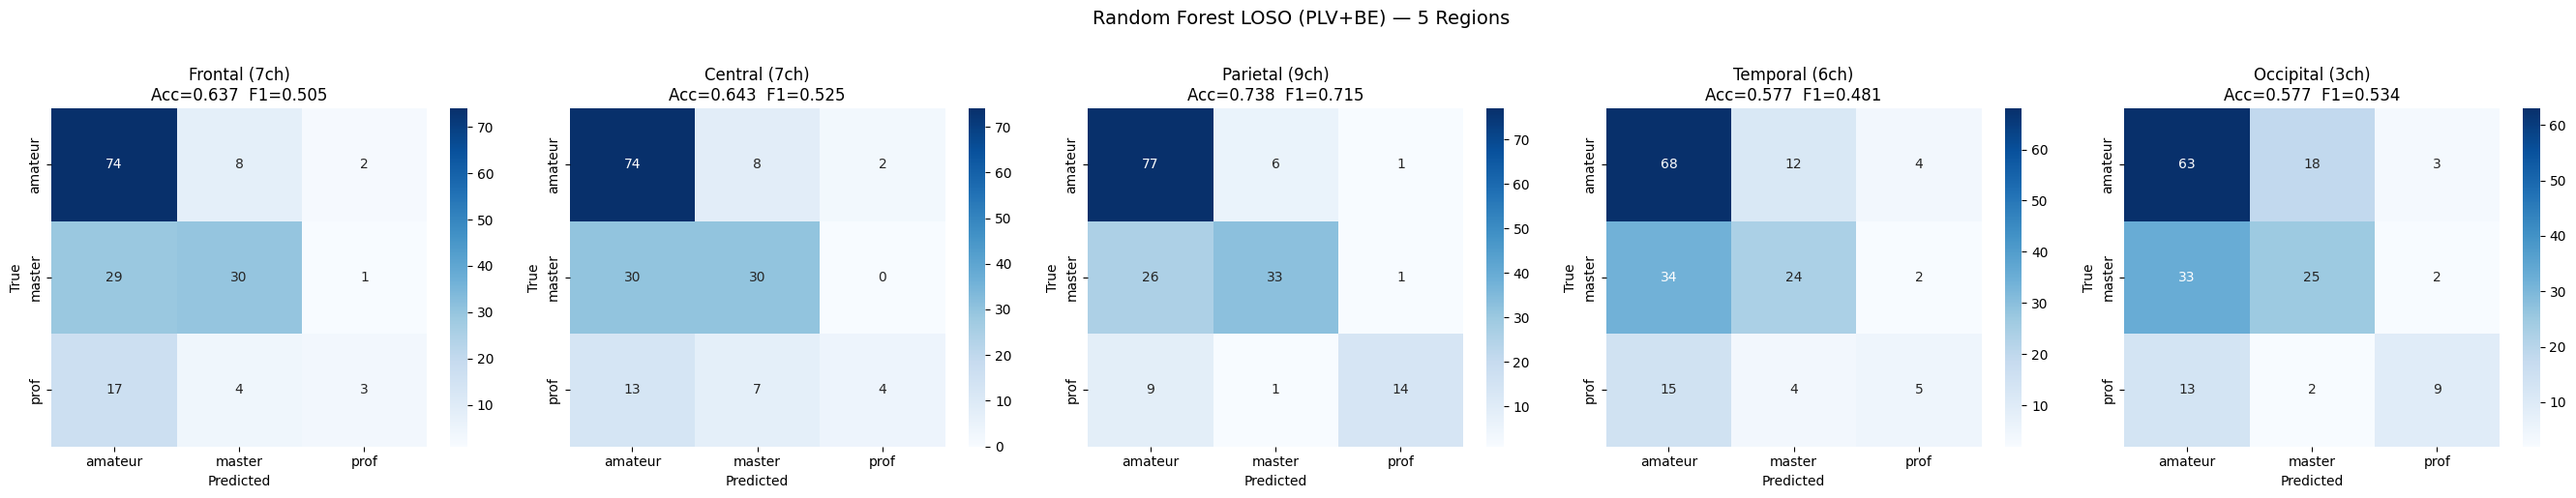

In [12]:
# ── 五腦區混淆矩陣 ──

fig, axes = plt.subplots(1, 5, figsize=(27, 5))
for ax, (region_name, r) in zip(axes, rf_results.items()):
    cm = confusion_matrix(r['true'], r['preds'], labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{region_name} ({len(r["ch_idx"])}ch)\nAcc={r["acc"]:.3f}  F1={r["f1"]:.3f}')

plt.suptitle('Random Forest LOSO (PLV+BE) — 5 Regions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\RF_PLV_BE\rf_plv_be_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── 各腦區 Classification Report ──

for region_name, r in rf_results.items():
    n_ch = len(r['ch_idx'])
    print(f'\n{"="*60}')
    print(f'{region_name} ({n_ch}ch)  Acc={r["acc"]:.3f}  F1={r["f1"]:.3f}')
    print(f'{"="*60}')
    print(classification_report(r['true'], r['preds'],
                                target_names=CLASS_NAMES, zero_division=0))


Frontal (7ch)  Acc=0.637  F1=0.505
              precision    recall  f1-score   support

     amateur       0.62      0.88      0.73        84
      master       0.71      0.50      0.59        60
        prof       0.50      0.12      0.20        24

    accuracy                           0.64       168
   macro avg       0.61      0.50      0.50       168
weighted avg       0.63      0.64      0.60       168


Central (7ch)  Acc=0.643  F1=0.525
              precision    recall  f1-score   support

     amateur       0.63      0.88      0.74        84
      master       0.67      0.50      0.57        60
        prof       0.67      0.17      0.27        24

    accuracy                           0.64       168
   macro avg       0.66      0.52      0.52       168
weighted avg       0.65      0.64      0.61       168


Parietal (9ch)  Acc=0.738  F1=0.715
              precision    recall  f1-score   support

     amateur       0.69      0.92      0.79        84
      master       0

Parietal — Hard Vote vs Soft Vote (Random Forest)
Subject             True    ss01    ss02    ss03    Hard    Soft      Soft Prob (am/ma/pr)   H   S
---------------------------------------------------------------------------------------------------------
sub-22           amateur amateur amateur amateur amateur amateur      [0.56 / 0.38 / 0.07]   O   O
sub-23           amateur amateur amateur amateur amateur amateur      [0.58 / 0.27 / 0.14]   O   O
sub-24           amateur amateur amateur    prof amateur amateur      [0.49 / 0.31 / 0.19]   O   O
sub-33           amateur  master amateur amateur amateur amateur      [0.51 / 0.34 / 0.15]   O   O
sub-38           amateur amateur amateur amateur amateur amateur      [0.64 / 0.26 / 0.10]   O   O
sub-39           amateur amateur amateur amateur amateur amateur      [0.62 / 0.30 / 0.07]   O   O
sub-40           amateur amateur amateur amateur amateur amateur      [0.60 / 0.28 / 0.12]   O   O
sub-41           amateur amateur amateur amateur ama

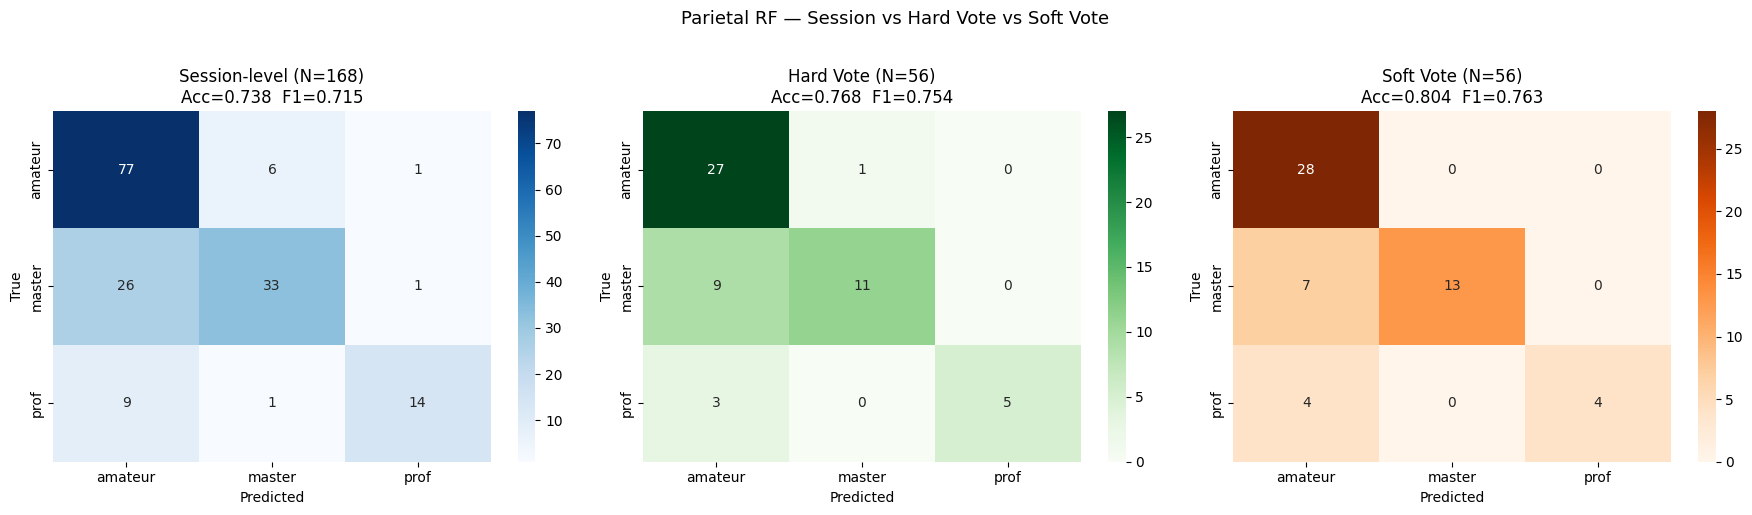

In [14]:
# ── Parietal：Session-level vs Subject-level Soft Vote ──
from scipy import stats

r = rf_results['Parietal']
preds_all = r['preds']
true_all  = r['true']
proba_all = r['proba']

print('=' * 105)
print('Parietal — Hard Vote vs Soft Vote (Random Forest)')
print('=' * 105)
print(f'{"Subject":<15s} {"True":>8s} {"ss01":>7s} {"ss02":>7s} {"ss03":>7s} '
      f'{"Hard":>7s} {"Soft":>7s} {"Soft Prob (am/ma/pr)":>25s} {"H":>3s} {"S":>3s}')
print('-' * 105)

hard_preds, soft_preds, vote_true = [], [], []

for i, sub_id in enumerate(subject_ids):
    true_label = subject_labels[sub_id]
    idx = slice(i*3, i*3+3)
    p1, p2, p3 = preds_all[i*3], preds_all[i*3+1], preds_all[i*3+2]
    hard = int(stats.mode([p1, p2, p3], keepdims=False).mode)
    mean_proba = proba_all[idx].mean(axis=0)
    soft = int(np.argmax(mean_proba))

    hard_preds.append(hard)
    soft_preds.append(soft)
    vote_true.append(true_label)

    h_mark = 'O' if hard == true_label else 'X'
    s_mark = 'O' if soft == true_label else 'X'
    prob_str = f'[{mean_proba[0]:.2f} / {mean_proba[1]:.2f} / {mean_proba[2]:.2f}]'
    print(f'{sub_id:<15s} {CLASS_NAMES[true_label]:>8s} '
          f'{CLASS_NAMES[int(p1)]:>7s} {CLASS_NAMES[int(p2)]:>7s} {CLASS_NAMES[int(p3)]:>7s} '
          f'{CLASS_NAMES[hard]:>7s} {CLASS_NAMES[soft]:>7s} {prob_str:>25s} {h_mark:>3s} {s_mark:>3s}')

hard_preds = np.array(hard_preds)
soft_preds = np.array(soft_preds)
vote_true  = np.array(vote_true)

hard_acc = accuracy_score(vote_true, hard_preds)
hard_f1  = f1_score(vote_true, hard_preds, average='macro', zero_division=0)
soft_acc = accuracy_score(vote_true, soft_preds)
soft_f1  = f1_score(vote_true, soft_preds, average='macro', zero_division=0)

print('=' * 105)
print(f'\nSession-level:  Acc = {r["acc"]:.3f}   F1 = {r["f1"]:.3f}   (N = {len(preds_all)} samples)')
print(f'Hard Vote:      Acc = {hard_acc:.3f}   F1 = {hard_f1:.3f}   (N = {len(hard_preds)} subjects)')
print(f'Soft Vote:      Acc = {soft_acc:.3f}   F1 = {soft_f1:.3f}   (N = {len(soft_preds)} subjects)')

# 混淆矩陣
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (cm, title, n) in zip(axes, [
    (confusion_matrix(true_all, preds_all, labels=[0,1,2]),
     f'Session-level (N={len(preds_all)})\nAcc={r["acc"]:.3f}  F1={r["f1"]:.3f}', 'Blues'),
    (confusion_matrix(vote_true, hard_preds, labels=[0,1,2]),
     f'Hard Vote (N={len(hard_preds)})\nAcc={hard_acc:.3f}  F1={hard_f1:.3f}', 'Greens'),
    (confusion_matrix(vote_true, soft_preds, labels=[0,1,2]),
     f'Soft Vote (N={len(soft_preds)})\nAcc={soft_acc:.3f}  F1={soft_f1:.3f}', 'Oranges'),
]):
    sns.heatmap(cm, annot=True, fmt='d', cmap=n,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)

plt.suptitle('Parietal RF — Session vs Hard Vote vs Soft Vote', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\RF_PLV_BE\rf_parietal_majority_vote.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── RF vs SVM 比較（需先跑過 svm_plv_be_combined.ipynb）──
import json

svm_json = r'D:\Tseng\game_eeg\SVM_PLV_BE\svm_plv_be_results.json'
try:
    with open(svm_json, 'r', encoding='utf-8') as f:
        svm_results = json.load(f)
    has_svm = True
except FileNotFoundError:
    print(f'找不到 {svm_json}，跳過 RF vs SVM 比較')
    has_svm = False

if has_svm:
    print('=' * 75)
    print('RF vs SVM — PLV+BE LOSO Comparison')
    print('=' * 75)
    print(f'{"Region":<12s} {"SVM Acc":>9s} {"RF Acc":>8s} {"Delta":>8s} {"SVM F1":>8s} {"RF F1":>7s}')
    print('-' * 75)
    for rn in REGIONS:
        s_acc = svm_results[rn]['acc']
        r_acc = rf_results[rn]['acc']
        s_f1  = svm_results[rn]['f1']
        r_f1  = rf_results[rn]['f1']
        print(f'{rn:<12s} {s_acc:9.3f} {r_acc:8.3f} {r_acc-s_acc:+8.3f} {s_f1:8.3f} {r_f1:7.3f}')
    print('=' * 75)

# 輸出 RF 結果供日後比對
rf_export = {rn: {'acc': float(v['acc']), 'f1': float(v['f1'])}
             for rn, v in rf_results.items()}
with open(r'D:\Tseng\game_eeg\RF_PLV_BE\rf_plv_be_results.json', 'w', encoding='utf-8') as f:
    json.dump(rf_export, f, indent=2)
print('\n結果已存至 RF_PLV_BE/rf_plv_be_results.json')

找不到 D:\Tseng\game_eeg\SVM_PLV_BE\svm_plv_be_results.json，跳過 RF vs SVM 比較

結果已存至 RF_PLV_BE/rf_plv_be_results.json


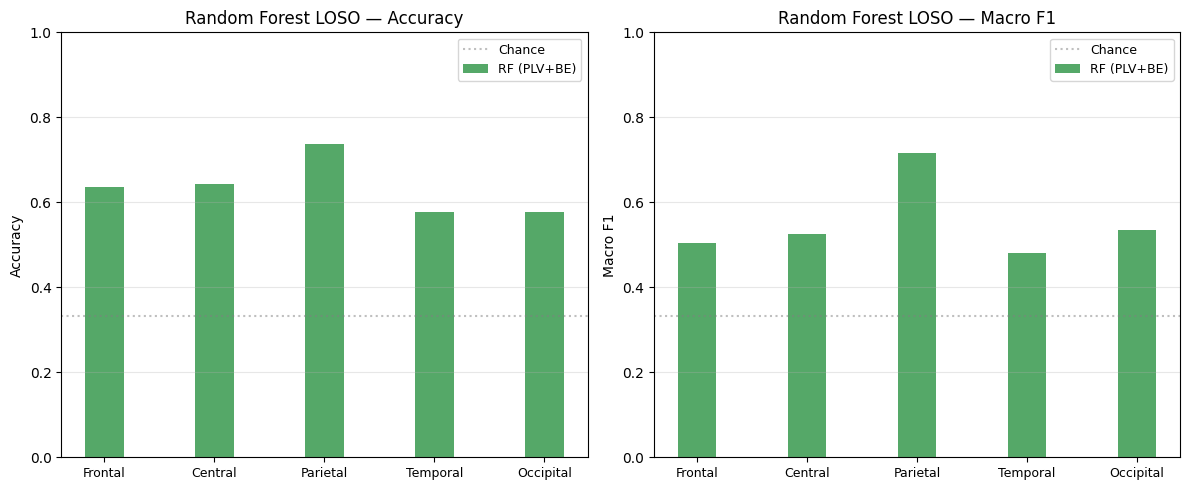

In [16]:
# ── 五腦區 Bar Chart ──

region_names = list(REGIONS.keys())
x = np.arange(len(region_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax_idx, (metric, title) in enumerate([('acc', 'Accuracy'), ('f1', 'Macro F1')]):
    ax = axes[ax_idx]
    rf_vals = [rf_results[rn][metric] for rn in region_names]
    ax.bar(x, rf_vals, width, label='RF (PLV+BE)', color='#55A868')
    ax.set_xticks(x)
    ax.set_xticklabels(region_names, fontsize=9)
    ax.set_ylabel(title)
    ax.set_title(f'Random Forest LOSO — {title}')
    ax.set_ylim(0, 1)
    ax.axhline(y=1/3, color='gray', linestyle=':', alpha=0.5, label='Chance')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\RF_PLV_BE\rf_plv_be_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ══════════════════════════════════════════════════════════════════
# 決策路徑分析 — Parietal
# 對每個 subject LOSO 重新訓練 RF，用 decision_path() 收集
# 每個 session 在每棵樹走過幾個節點、預測信心值等資訊
# ══════════════════════════════════════════════════════════════════

import pandas as pd

ch_idx   = REGIONS['Parietal']
feat_plv = extract_plv_features(X_plv, ch_idx)
feat_be  = extract_be_features(X_be,  ch_idx)

path_records = []

for test_subject in subject_ids:
    test_mask  = subject_split == test_subject
    train_mask = ~test_mask
    y_tr = y_all[train_mask].astype(int)
    y_te = y_all[test_mask].astype(int)

    sc_p  = StandardScaler()
    plv_tr = sc_p.fit_transform(feat_plv[train_mask])
    plv_te = sc_p.transform(feat_plv[test_mask])
    pca_p = PCA(n_components=0.95)
    plv_tr = pca_p.fit_transform(plv_tr)
    plv_te = pca_p.transform(plv_te)

    sc_b  = StandardScaler()
    be_tr  = sc_b.fit_transform(feat_be[train_mask])
    be_te  = sc_b.transform(feat_be[test_mask])
    pca_b = PCA(n_components=0.95)
    be_tr  = pca_b.fit_transform(be_tr)
    be_te  = pca_b.transform(be_te)

    X_tr = np.hstack([plv_tr, be_tr])
    X_te = np.hstack([plv_te, be_te])

    clf = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
    clf.fit(X_tr, y_tr)

    for ses_idx, (x_row, y_row) in enumerate(zip(X_te, y_te)):
        x_2d  = x_row.reshape(1, -1)
        pred  = clf.predict(x_2d)[0]
        proba = clf.predict_proba(x_2d)[0]
        node_counts = [clf.estimators_[k].decision_path(x_2d).nnz
                       for k in range(len(clf.estimators_))]
        path_records.append({
            'subject':    test_subject,
            'true_label': CLASS_NAMES[y_row],
            'pred_label': CLASS_NAMES[pred],
            'correct':    pred == y_row,
            'session':    f'ss0{ses_idx+1}',
            'prob_am':    proba[0],
            'prob_ma':    proba[1],
            'prob_pr':    proba[2],
            'conf':       float(proba[pred]),
            'mean_nodes': float(np.mean(node_counts)),
            'std_nodes':  float(np.std(node_counts)),
        })

df_path = pd.DataFrame(path_records)
print(f'共 {len(df_path)} 筆 session 路徑記錄（{len(subject_ids)} subjects × 3 sessions）')
df_path.head(6)

共 168 筆 session 路徑記錄（56 subjects × 3 sessions）


,subject,true_label,pred_label,correct,session,prob_am,prob_ma,prob_pr,conf,mean_nodes,std_nodes
0,sub-22,amateur,amateur,True,ss01,0.586,0.344,0.070,0.586,6.822,1.824915
1,sub-22,amateur,amateur,True,ss02,0.586,0.328,0.086,0.586,6.880,1.873393
2,sub-22,amateur,amateur,True,ss03,0.498,0.454,0.048,0.498,7.020,1.782021
3,sub-23,amateur,amateur,True,ss01,0.726,0.234,0.040,0.726,6.008,1.831921
4,sub-23,amateur,amateur,True,ss02,0.538,0.240,0.222,0.538,6.316,1.577385
5,sub-23,amateur,amateur,True,ss03,0.488,0.344,0.168,0.488,6.738,1.793699


In [18]:
# ── 每個 Subject 的決策路徑摘要表 ──
# true class / 3 session 預測結果 & 信心值 / 平均路徑節點數

print('=' * 115)
print('Parietal — RF Decision Path Summary  (每棵樹平均走過節點數 = 路徑長度)')
print('=' * 115)
print(f'{"Subject":<15s} {"True":>8s} '
      f'{"ss01 pred(conf)":>16s} {"ss02 pred(conf)":>16s} {"ss03 pred(conf)":>16s} '
      f'{"Avg Nodes":>10s} {"OK/3":>5s}')
print('-' * 115)

for sub_id in subject_ids:
    rows = df_path[df_path['subject'] == sub_id].sort_values('session')
    true_lbl  = rows.iloc[0]['true_label']
    ses_strs  = []
    n_correct = 0
    all_nodes = []
    for _, row in rows.iterrows():
        marker = 'O' if row['correct'] else 'X'
        ses_strs.append(f"{row['pred_label'][:4]}({row['conf']:.2f}){marker}")
        n_correct += int(row['correct'])
        all_nodes.append(row['mean_nodes'])
    avg_nodes = np.mean(all_nodes)
    print(f'{sub_id:<15s} {true_lbl:>8s} '
          f'{ses_strs[0]:>16s} {ses_strs[1]:>16s} {ses_strs[2]:>16s} '
          f'{avg_nodes:10.1f} {n_correct:>4d}/3')

print('=' * 115)
print(f'\n整體 session Acc = {df_path["correct"].mean():.3f}  '
      f'正確={df_path["correct"].sum()}/{len(df_path)}')
print(f'平均路徑長度 = {df_path["mean_nodes"].mean():.1f} 節點/樹  '
      f'(正確: {df_path[df_path["correct"]]["mean_nodes"].mean():.1f}  '
      f'錯誤: {df_path[~df_path["correct"]]["mean_nodes"].mean():.1f})')


Parietal — RF Decision Path Summary  (每棵樹平均走過節點數 = 路徑長度)
Subject             True  ss01 pred(conf)  ss02 pred(conf)  ss03 pred(conf)  Avg Nodes  OK/3
-------------------------------------------------------------------------------------------------------------------
sub-22           amateur      amat(0.59)O      amat(0.59)O      amat(0.50)O        6.9    3/3
sub-23           amateur      amat(0.73)O      amat(0.54)O      amat(0.49)O        6.4    3/3
sub-24           amateur      amat(0.49)O      amat(0.61)O      prof(0.41)X        6.4    2/3
sub-33           amateur      mast(0.40)X      amat(0.49)O      amat(0.65)O        6.6    2/3
sub-38           amateur      amat(0.65)O      amat(0.69)O      amat(0.57)O        6.3    3/3
sub-39           amateur      amat(0.66)O      amat(0.60)O      amat(0.61)O        6.8    3/3
sub-40           amateur      amat(0.76)O      amat(0.45)O      amat(0.59)O        6.7    3/3
sub-41           amateur      amat(0.61)O      amat(0.63)O      amat(0.47)O 

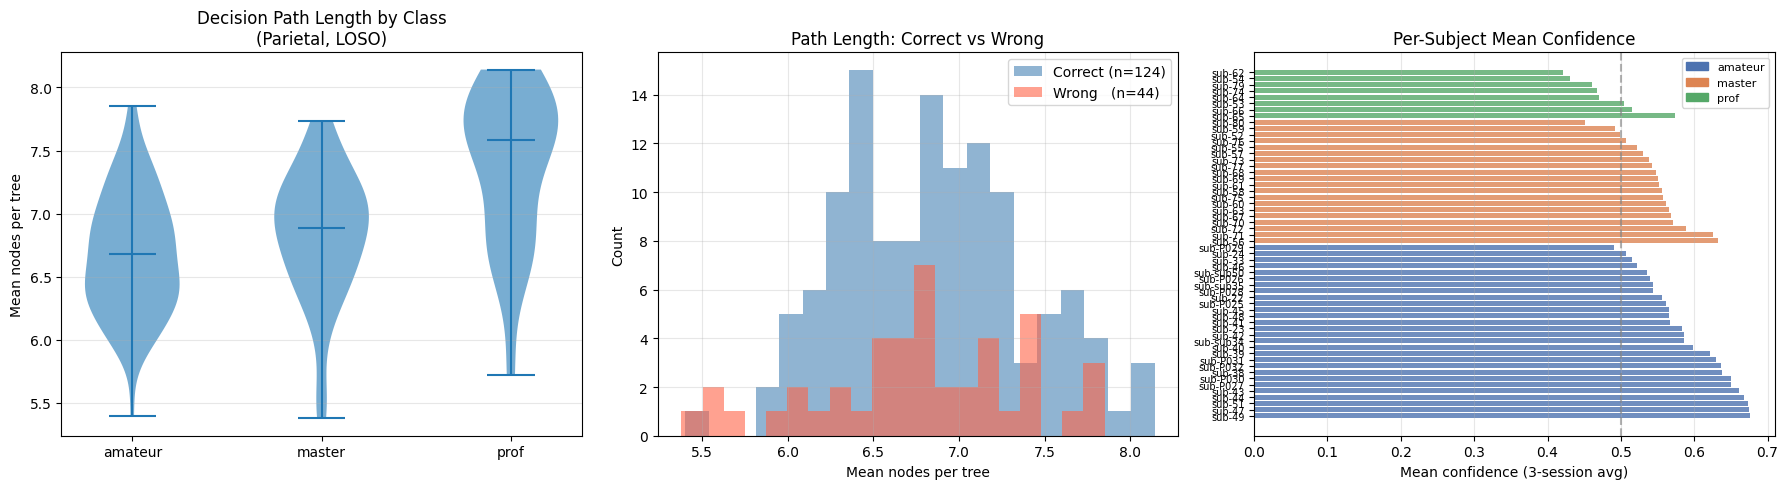

高信心(>0.6)但分類錯誤: 5 sessions
subject true_label pred_label  conf session
 sub-56     master    amateur 0.750    ss01
 sub-67     master    amateur 0.624    ss03
 sub-69     master    amateur 0.668    ss01
 sub-71     master    amateur 0.664    ss02
 sub-53       prof    amateur 0.658    ss02


In [19]:
# ── 路徑長度分佈 + 信心值分析 ──

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 各 class 路徑長度 violin
ax = axes[0]
groups = [df_path[df_path['true_label'] == c]['mean_nodes'].values for c in CLASS_NAMES]
vp = ax.violinplot(groups, positions=[0,1,2], showmedians=True)
for body in vp['bodies']:
    body.set_alpha(0.6)
ax.set_xticks([0,1,2])
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('Mean nodes per tree')
ax.set_title('Decision Path Length by Class\n(Parietal, LOSO)')
ax.grid(axis='y', alpha=0.3)

# 2) 正確 vs 錯誤 路徑長度
ax = axes[1]
ax.hist(df_path[df_path['correct']]['mean_nodes'],  bins=20, alpha=0.6,
        color='steelblue', label=f'Correct (n={df_path["correct"].sum()})')
ax.hist(df_path[~df_path['correct']]['mean_nodes'], bins=20, alpha=0.6,
        color='tomato',    label=f'Wrong   (n={(~df_path["correct"]).sum()})')
ax.set_xlabel('Mean nodes per tree')
ax.set_ylabel('Count')
ax.set_title('Path Length: Correct vs Wrong')
ax.legend(); ax.grid(alpha=0.3)

# 3) per-subject 平均信心值
ax = axes[2]
sub_conf = df_path.groupby('subject')['conf'].mean().reset_index()
sub_conf['true_label'] = sub_conf['subject'].map(lambda s: CLASS_NAMES[subject_labels[s]])
sub_conf = sub_conf.sort_values(['true_label','conf'], ascending=[True, False])
color_map = {'amateur': '#4C72B0', 'master': '#DD8452', 'prof': '#55A868'}
bar_colors = [color_map[lbl] for lbl in sub_conf['true_label']]
ax.barh(range(len(sub_conf)), sub_conf['conf'], color=bar_colors, alpha=0.8)
ax.set_yticks(range(len(sub_conf)))
ax.set_yticklabels(sub_conf['subject'], fontsize=7)
ax.set_xlabel('Mean confidence (3-session avg)')
ax.set_title('Per-Subject Mean Confidence')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.6)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v, label=k) for k,v in color_map.items()], fontsize=8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\RF_PLV_BE\rf_path_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

high_wrong = df_path[(df_path['conf'] > 0.6) & ~df_path['correct']]
print(f'高信心(>0.6)但分類錯誤: {len(high_wrong)} sessions')
if len(high_wrong):
    print(high_wrong[['subject','true_label','pred_label','conf','session']].to_string(index=False))


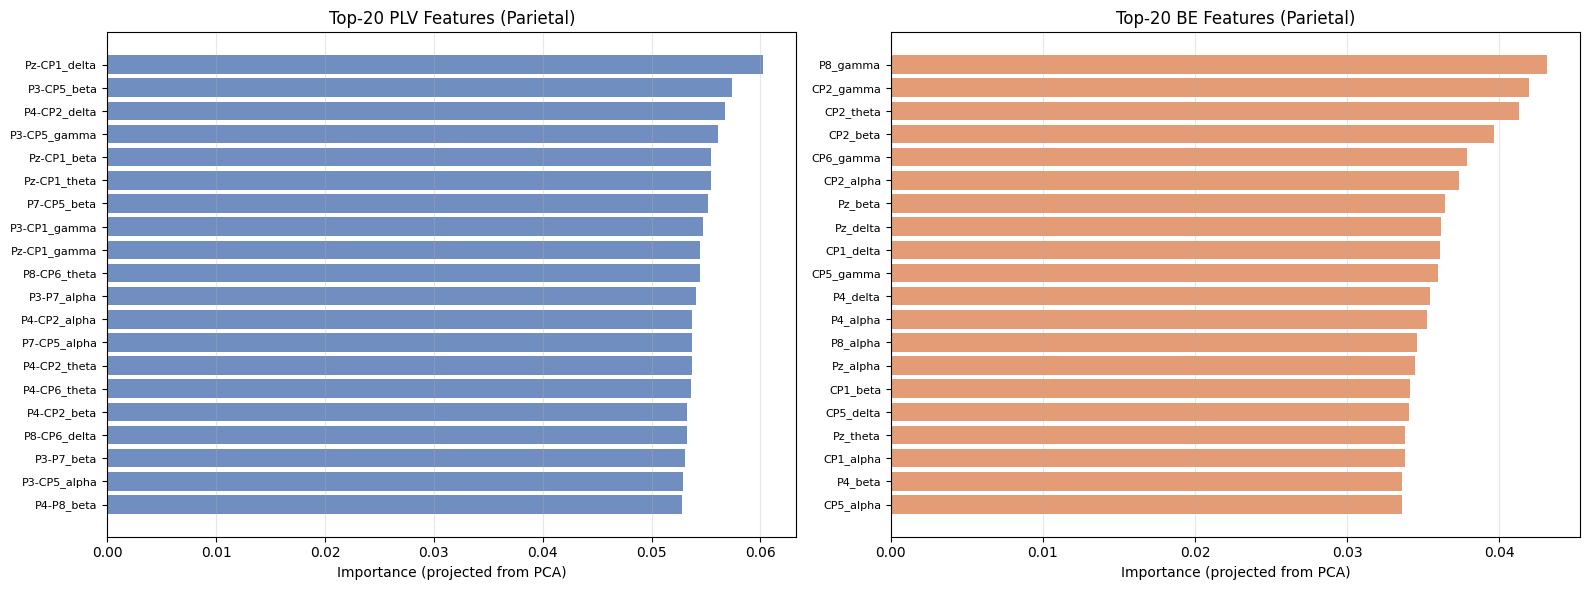

PLV branch importance 總和 = 0.744
BE  branch importance 總和 = 0.256


In [20]:
# ── Feature Importance（原始 PLV / BE 特徵空間）──
# RF importance 定義在 PCA 空間；投影回原始空間以便解讀

ch_idx = REGIONS['Parietal']
fp_raw = extract_plv_features(X_plv, ch_idx)
fb_raw = extract_be_features(X_be, ch_idx)
sc_p2 = StandardScaler(); fp_raw = sc_p2.fit_transform(fp_raw)
pca_p2 = PCA(n_components=0.95); fp_raw = pca_p2.fit_transform(fp_raw)
sc_b2 = StandardScaler(); fb_raw = sc_b2.fit_transform(fb_raw)
pca_b2 = PCA(n_components=0.95); fb_raw = pca_b2.fit_transform(fb_raw)
X_full2 = np.hstack([fp_raw, fb_raw])

rf_full2 = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_full2.fit(X_full2, y_all.astype(int))

n_plv_pcs2 = fp_raw.shape[1]
n_be_pcs2  = fb_raw.shape[1]
imp = rf_full2.feature_importances_

imp_plv_orig = np.abs(pca_p2.components_).T @ imp[:n_plv_pcs2]
imp_be_orig  = np.abs(pca_b2.components_).T @ imp[n_plv_pcs2:]

ch_names_pari = [CH_NAMES[i] for i in REGIONS['Parietal']]
n_ch = len(ch_names_pari)
pairs = [(ch_names_pari[i], ch_names_pari[j])
         for i in range(n_ch) for j in range(i+1, n_ch)]
plv_feat_names = [f'{a}-{b}_{bnd}' for bnd in BAND_NAMES for a, b in pairs]
be_feat_names  = [f'{ch}_{b}' for ch in ch_names_pari for b in BAND_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
top20 = np.argsort(imp_plv_orig)[::-1][:20]
ax.barh(range(20), imp_plv_orig[top20][::-1], color='#4C72B0', alpha=0.8)
ax.set_yticks(range(20))
ax.set_yticklabels([plv_feat_names[i] for i in top20[::-1]], fontsize=8)
ax.set_xlabel('Importance (projected from PCA)')
ax.set_title('Top-20 PLV Features (Parietal)')
ax.grid(axis='x', alpha=0.3)

ax = axes[1]
top_be = np.argsort(imp_be_orig)[::-1][:20]
ax.barh(range(len(top_be)), imp_be_orig[top_be][::-1], color='#DD8452', alpha=0.8)
ax.set_yticks(range(len(top_be)))
ax.set_yticklabels([be_feat_names[i] for i in top_be[::-1]], fontsize=8)
ax.set_xlabel('Importance (projected from PCA)')
ax.set_title('Top-20 BE Features (Parietal)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\RF_PLV_BE\rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'PLV branch importance 總和 = {imp[:n_plv_pcs2].sum():.3f}')
print(f'BE  branch importance 總和 = {imp[n_plv_pcs2:].sum():.3f}')


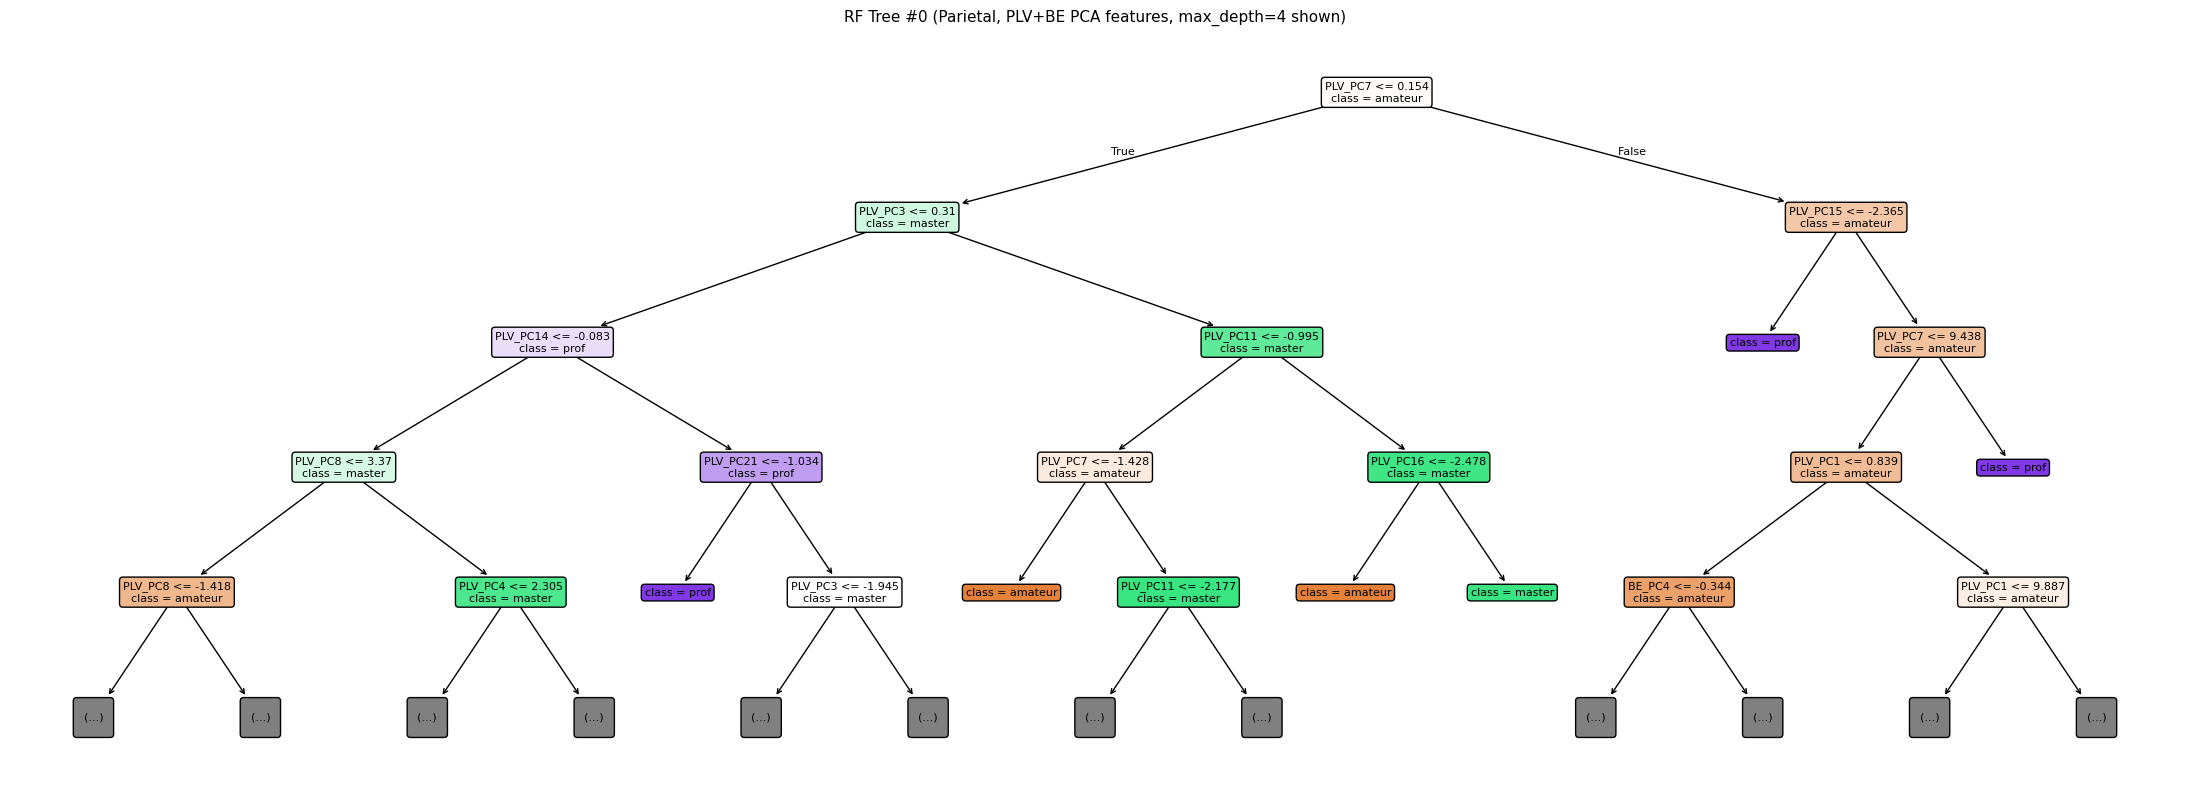

樹的實際深度: 9  (圖只顯示前 4 層)


In [21]:
# ── 單棵決策樹視覺化（max_depth=4，方便閱讀）──
from sklearn.tree import plot_tree

feat_names2 = ([f'PLV_PC{i+1}' for i in range(n_plv_pcs2)] +
               [f'BE_PC{i+1}'  for i in range(n_be_pcs2)])

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    rf_full2.estimators_[0],
    max_depth=4,
    feature_names=feat_names2,
    class_names=CLASS_NAMES,
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=8,
    ax=ax
)

# 只保留決策條件（<=）和 class 行，移除 samples / value
for artist in ax.get_children():
    if hasattr(artist, 'get_text') and artist.get_text():
        lines = artist.get_text().split('\n')
        kept = [l for l in lines if '<=' in l or 'class' in l]
        if kept:
            artist.set_text('\n'.join(kept))

ax.set_title('RF Tree #0 (Parietal, PLV+BE PCA features, max_depth=4 shown)', fontsize=11)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\RF_PLV_BE\rf_single_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'樹的實際深度: {rf_full2.estimators_[0].get_depth()}  (圖只顯示前 4 層)')